In [1]:
!pip install mediapy

In [2]:
import os
import mujoco
import mediapy as media
import numpy as np

# Pointing exactly to the right-hand scene file 
MODEL_PATH = "mujoco_menagerie/wonik_allegro/scene_right.xml"

# Load the model
model = mujoco.MjModel.from_xml_path(MODEL_PATH)
data = mujoco.MjData(model)

print("The MuJoCo model loaded.")

The MuJoCo model loaded.


In [3]:
# Quick sanity check: print basic model info
print(f"nq (DOF positions): {model.nq}")   
print(f"nv (DOF velocities): {model.nv}")  
print(f"nu (actuators):      {model.nu}")  
print(f"nbody:               {model.nbody}")

# List all joint names
for i in range(model.njnt):
    print(f"  joint {i:2d}: {model.joint(i).name}")

nq (DOF positions): 17
nv (DOF velocities): 17
nu (actuators):      17
nbody:               23
  joint  0: lift
  joint  1: ffj0
  joint  2: ffj1
  joint  3: ffj2
  joint  4: ffj3
  joint  5: mfj0
  joint  6: mfj1
  joint  7: mfj2
  joint  8: mfj3
  joint  9: rfj0
  joint 10: rfj1
  joint 11: rfj2
  joint 12: rfj3
  joint 13: thj0
  joint 14: thj1
  joint 15: thj2
  joint 16: thj3


""

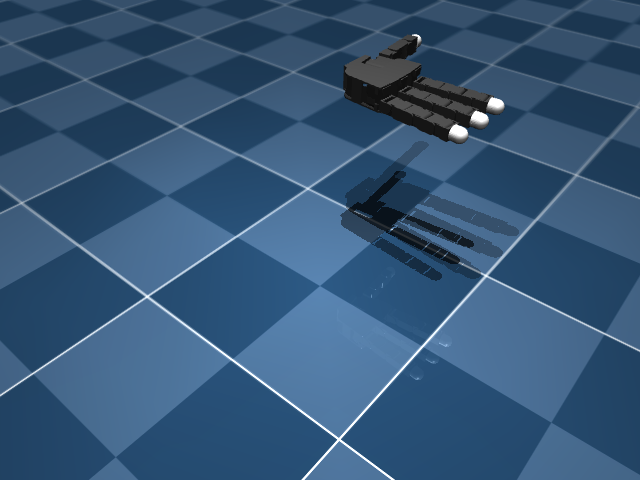

In [4]:
# Render a single frame
renderer = mujoco.Renderer(model, height=480, width=640)

mujoco.mj_resetData(model, data)   # reset to keyframe 0
mujoco.mj_forward(model, data)     # compute forward kinematics

renderer.update_scene(data)
media.show_image(renderer.render())

In [5]:
# Render a short passive simulation video (hand just falls/settles under gravity)
mujoco.mj_resetData(model, data)

duration = 2.0   # seconds
fps      = 30
frames   = []

while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * fps:
        renderer.update_scene(data)
        frames.append(renderer.render())

media.show_video(frames, fps=fps)

This browser does not support the video tag.


# SIMULATION: PART 1

****Combining everything in one function****

In [6]:
import matplotlib.pyplot as plt

def run_grasp_trial(xml_path, obj_name, label, duration=6.0, fps=30, render=True):
    """
    Runs the standard open->close->lift grasp sequence on a given scene,
    and returns a results dict with full time-series data for plotting + comparison.
    """
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)
    renderer = mujoco.Renderer(model, height=480, width=640) if render else None

    OPEN_POSE   = np.array([0.0, -0.1, 0.0, 0.0] * 4)
    CLOSED_POSE = np.array([
        0.0, 1.6, 1.7, 1.4,   # index  
        0.0, 1.6, 1.7, 1.4,   # middle
        0.0, 1.6, 1.7, 1.4,   # ring
        0.9, 1.15, 1.6, 1.7,  # thumb 
    ])
    LIFT_DOWN, LIFT_UP = -0.05, 0.05

    def set_finger_targets(pose):
        data.ctrl[1:17] = pose

    def set_lift(pos):
        data.ctrl[0] = pos

    def get_closing_pose(t, start=0.5, duration=1.5):
        alpha = np.clip((t - start) / duration, 0, 1)
        return OPEN_POSE + alpha * (CLOSED_POSE - OPEN_POSE)

    mujoco.mj_resetData(model, data)

    FINGERTIP_BODIES = ["ff_tip", "mf_tip", "rf_tip", "th_tip"]
    tip_ids = [model.body(n).id for n in FINGERTIP_BODIES]
    palm_id = model.body("palm").id

    results = {
        "label": label,
        "t": [],
        "forces": {n: [] for n in FINGERTIP_BODIES},
        "palm_force": [],
        "obj_pos": [],
        "hand_z": [],
    }
    frames = []

    while data.time < duration:
        if data.time < 0.5:
            set_finger_targets(OPEN_POSE); set_lift(LIFT_DOWN)
        elif data.time < 2.0:
            set_finger_targets(get_closing_pose(data.time)); set_lift(LIFT_DOWN)
        else:
            set_finger_targets(CLOSED_POSE); set_lift(LIFT_UP)

        mujoco.mj_step(model, data)
        mujoco.mj_rnePostConstraint(model, data)   # populate cfrc_ext

        if render and len(frames) < data.time * fps:
            renderer.update_scene(data)
            frames.append(renderer.render())

        results["t"].append(data.time)
        for n, bid in zip(FINGERTIP_BODIES, tip_ids):
            results["forces"][n].append(np.linalg.norm(data.cfrc_ext[bid, 3:6]))
        results["palm_force"].append(np.linalg.norm(data.cfrc_ext[palm_id, 3:6]))
        results["obj_pos"].append(data.body(obj_name).xpos.copy())
        results["hand_z"].append(data.xpos[palm_id][2])

    peak = {n: max(results["forces"][n]) for n in FINGERTIP_BODIES}
    print(f"[{label}] done. peak forces: " + ", ".join(f"{n}={v:.2f}" for n, v in peak.items()))

    return results, frames

In [7]:
# Running simulation for object in custom_scene: hardest object
results_rigid, frames_rigid = run_grasp_trial(
    "mujoco_menagerie/wonik_allegro/custom_scene.xml", "object", "rigid"
)
media.show_video(frames_rigid, fps=30)

[rigid] done. peak forces: ff_tip=8.74, mf_tip=16.17, rf_tip=15.32, th_tip=9.64


This browser does not support the video tag.


In [8]:
# Running simulation for object1 in custom_scene1: medium-hard object
results_medium, frames_medium = run_grasp_trial(
    "mujoco_menagerie/wonik_allegro/custom_scene1.xml", "object1", "medium"
)
media.show_video(frames_medium, fps=30)

[medium] done. peak forces: ff_tip=8.65, mf_tip=14.13, rf_tip=14.86, th_tip=9.14


This browser does not support the video tag.


In [9]:
# Running simulation for object2 in custom_scene2: softest object
results_soft, frames_soft = run_grasp_trial(
    "mujoco_menagerie/wonik_allegro/custom_scene2.xml", "object2", "soft"
)
media.show_video(frames_soft, fps=30)

[soft] done. peak forces: ff_tip=8.16, mf_tip=8.06, rf_tip=8.14, th_tip=5.16


This browser does not support the video tag.


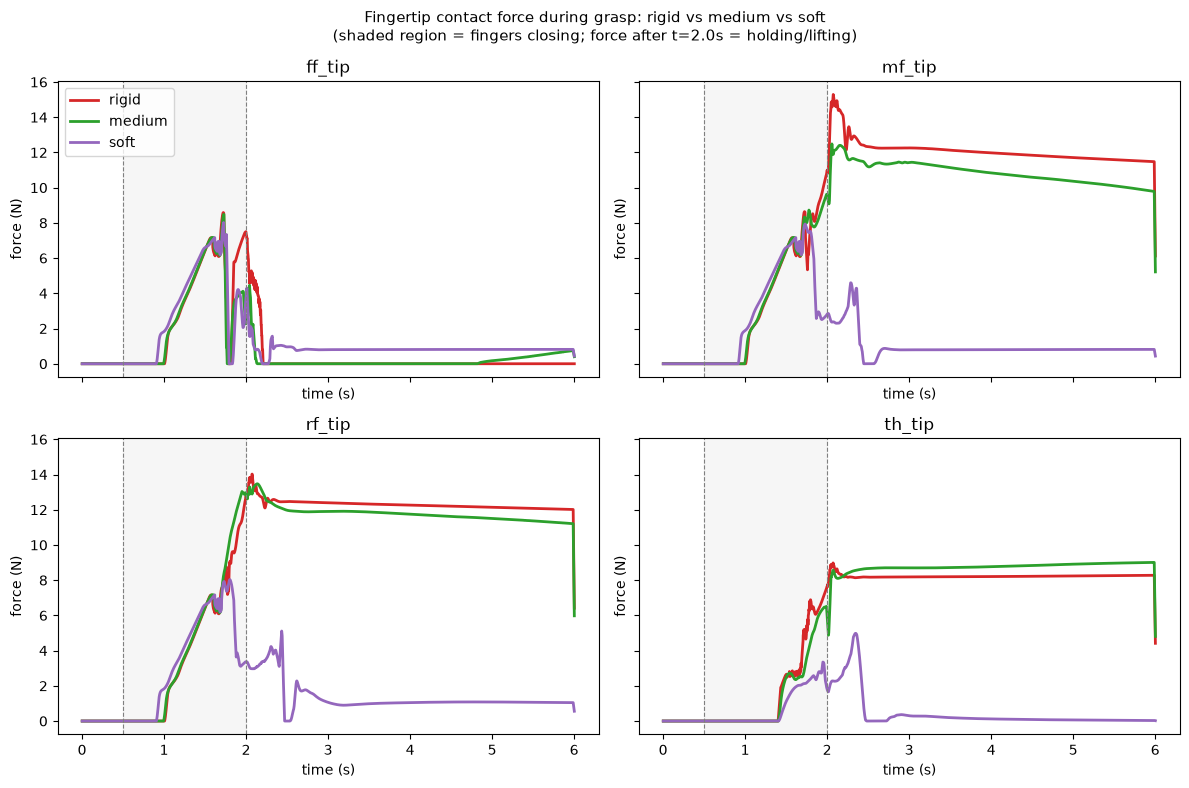

In [10]:
# Plotting the resulting contact forces
def smooth(y, window=15): # smooth y for a readable plot
    y = np.array(y)
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='same')

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
finger_names = ["ff_tip", "mf_tip", "rf_tip", "th_tip"]
colors = {"rigid": "tab:red", "medium": "tab:green", "soft": "tab:purple"}

for ax, finger in zip(axes.flat, finger_names):
    for res in [results_rigid, results_medium, results_soft]:
        ax.plot(res["t"], smooth(res["forces"][finger]),
                label=res["label"], color=colors[res["label"]], linewidth=2)

    # mark the phase transitions so the shape of the curve makes sense at a glance
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(2.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axvspan(0.5, 2.0, color="gray", alpha=0.07)

    ax.set_title(finger)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("force (N)")

axes.flat[0].legend(loc="upper left")
fig.suptitle("Fingertip contact force during grasp: rigid vs medium vs soft\n"
             "(shaded region = fingers closing; force after t=2.0s = holding/lifting)",
             fontsize=11)
plt.tight_layout()
plt.savefig("finger_forces_comparison_clean.png", dpi=150)
plt.show()

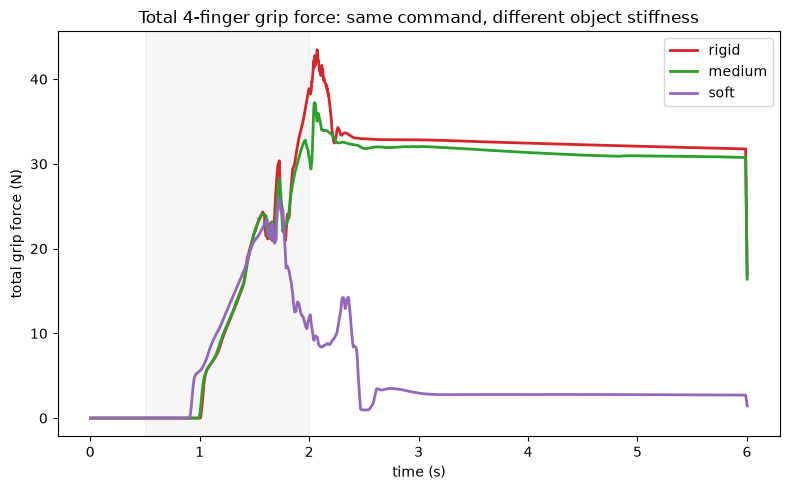

In [11]:
plt.figure(figsize=(8,5))
for res in [results_rigid, results_medium, results_soft]:
    total_force = np.sum([res["forces"][f] for f in finger_names], axis=0)
    plt.plot(res["t"], smooth(total_force), label=res["label"], color=colors[res["label"]], linewidth=2)
plt.axvspan(0.5, 2.0, color="gray", alpha=0.07)
plt.xlabel("time (s)"); plt.ylabel("total grip force (N)")
plt.title("Total 4-finger grip force: same command, different object stiffness")
plt.legend()
plt.tight_layout()
plt.savefig("total_grip_force.png", dpi=150)
plt.show()

In [12]:
def summarize_extra(res):
    palm = np.array(res["palm_force"])
    obj_pos = np.array(res["obj_pos"])          # shape (T, 3)
    hand_z  = np.array(res["hand_z"])
    t       = np.array(res["t"])

    peak_palm = palm.max()
    # drift = how far the object moves from its start position, in the XY plane
    xy_drift = np.linalg.norm(obj_pos[:, :2] - obj_pos[0, :2], axis=1).max()
    # settle: how much object height changes from start to end (rise/fall)
    z_change = obj_pos[-1, 2] - obj_pos[0, 2]
    # gap at the end of the trial (hold+lift phase)
    final_gap = hand_z[-1] - obj_pos[-1, 2]

    print(f"[{res['label']}] peak palm force: {peak_palm:.2f} N | "
          f"max XY drift: {xy_drift*100:.2f} cm | "
          f"object height change: {z_change*100:.2f} cm | "
          f"final gap: {final_gap:.3f}")

for res in [results_rigid, results_medium, results_soft]:
    summarize_extra(res)

[rigid] peak palm force: 184.93 N | max XY drift: 4.57 cm | object height change: 1.33 cm | final gap: 0.052
[medium] peak palm force: 50.18 N | max XY drift: 4.99 cm | object height change: 1.22 cm | final gap: 0.053
[soft] peak palm force: 21.32 N | max XY drift: 8.62 cm | object height change: 1.46 cm | final gap: 0.082


# ESO: PART 2

In [13]:
# Finger pose definitions
# Each pose is a 16-element array: 4 joints x 4 fingers, in order
# [ff j0-j3, mf j0-j3, rf j0-j3, th j0-j3]. These feed directly into
# data.ctrl[1:17] (index 0 is the separate lift actuator).

# Fingers fully open: j0 (spread) = 0, j1 (proximal) pulled back slightly,
# j2/j3 straight. This is the starting pose before any grasp attempt.
OPEN_POSE   = np.array([0.0, -0.1, 0.0, 0.0] * 4)

# Fingers curled into a grasp. We set j3 (distal joint) to 1.4, not the
# joint's mechanical max (1.618). Pulling back from the hard limit avoids
# a large joint-limit collision spike that would otherwise contaminate any
# force/torque reading taken near full closure (this became a problem during early
# mfj3 calibration attempts).
CLOSED_POSE = np.array([
    0.0, 1.6, 1.7, 1.4,   # index  (ffj0-3)
    0.0, 1.6, 1.7, 1.4,   # middle (mfj0-3)
    0.0, 1.6, 1.7, 1.4,   # ring   (rfj0-3)
    0.9, 1.15, 1.6, 1.7,  # thumb  (thj0-3)
])

# Lift joint target positions (slide joint on the wrist, separate actuator
# at data.ctrl[0]). Negative = down/toward the object, positive = up/lift.
LIFT_DOWN = -0.05
LIFT_UP   = 0.05

def get_opening_pose(t, duration=0.3): # ramp into OPEN_POSE smoothly from wherever qpos actually starts
    """
    Smoothly ramp from all-zero into OPEN_POSE over `duration` seconds,
    starting at t=0. Uses a minimum-jerk profile rather than a
    step function or simple linear ramp: minimum-jerk has zero velocity
    and zero acceleration at both endpoints (t=0 and t=duration).
    A simpler cubic smoothstep only guarantees zero velocity, and the
    resulting acceleration discontinuity was large enough to show up as
    a real spike in the ESO's disturbance estimate (it looks like contact
    when it's actually just an artifact of how the target changes shape).
    """
    alpha = np.clip(t / duration, 0, 1)
    alpha_smooth = 6*alpha**5 - 15*alpha**4 + 10*alpha**3   # minimum-jerk polynomial
    return alpha_smooth * OPEN_POSE

def get_closing_pose(t, start=0.6, duration=1.5): 
    """Same minimum-jerk ramp, but from OPEN_POSE to CLOSED_POSE, starting at t=start."""
    alpha = np.clip((t - start) / duration, 0, 1)
    alpha_smooth = 6*alpha**5 - 15*alpha**4 + 10*alpha**3   # minimum-jerk
    return OPEN_POSE + alpha_smooth * (CLOSED_POSE - OPEN_POSE)

def set_finger_targets(data, pose):
    """Write a 16-element finger pose into data.ctrl."""
    data.ctrl[1:17] = pose

def set_lift(data, pos):
    """Set the lift actuator's target position."""
    data.ctrl[0] = pos

In [14]:
# Sanity check calculating analytic joint inertia
# Before doing the full empirical calibration, we want to get a rough estimate for b0
# using MuJoCo's own mass matrix. This doesn't account for coupling with
# other joints properly (it uses only the diagonal entry), so the resulting
# number is expected to be an underestimate. It's a reference point to
# compare the real calibration against, not the value we actually use.
model_cal = mujoco.MjModel.from_xml_path("mujoco_menagerie/wonik_allegro/scene_right.xml")
data_cal = mujoco.MjData(model_cal)
data_cal.qpos[:] = 0
mujoco.mj_forward(model_cal, data_cal) # compute mass matrix at this pose, without stepping time

# mj_fullM expands MuJoCo's internal sparse mass matrix representation (data.qM) 
# into a normal dense (nv x nv) numpy array we can index directly.
M_full = np.zeros((model_cal.nv, model_cal.nv))
mujoco.mj_fullM(model_cal, M_full, data_cal.qM)
mfj1_dof = model_cal.joint("mfj1").dofadr[0]

# mfj1's inertia is ~55x larger than mfj3's
# This is why mfj1 we chose mfj1:
# small joint inertia forces a huge b0, which massively amplifies any small
# model-mismatch through the observer's feedback gains (this is what made
# the earlier mfj3 attempt unstable).
print(f"mfj1 own inertia M[mfj1,mfj1]: {M_full[mfj1_dof, mfj1_dof]:.6f}")
print(f"mfj3 own inertia M[mfj3,mfj3] (for comparison): {M_full[model_cal.joint('mfj3').dofadr[0], model_cal.joint('mfj3').dofadr[0]]:.8f}")
print(f"Naive b0 (1/M) for mfj1: {1.0/M_full[mfj1_dof,mfj1_dof]:.4f}")

mfj1 own inertia M[mfj1,mfj1]: 0.000314
mfj3 own inertia M[mfj3,mfj3] (for comparison): 0.00000565
Naive b0 (1/M) for mfj1: 3189.6384


mfj1 settled after 5922 steps (t=11.846s)
Estimated b0 for mfj1: 15662.7416


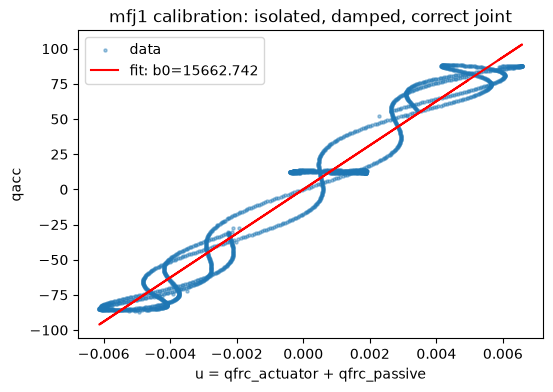

In [15]:
# Real Calibration: isolated sine sweep for mfj1
# Goal: measure b0 empirically by moving only mfj1 and recording how its
# torque (u) relates to its resulting acceleration (qacc). To get a clean
# measurement, every other confounding factor needed to be removed:
# 1. gravity OFF: otherwise gravity's contribution (which varies with pose)
# gets mixed into the torque-acceleration relationship and biases the fit
# 2. all other joints held fixed: otherwise their motion couples into mfj1's
# acceleration through the mass matrix's off-diagonal terms, and that
# coupling has nothing to do with mfj1's own dynamics. This was the
# source of the loop-shaped (non-linear) calibration plots we saw before
# isolating the joint
# 3. damping temporarily boosted 20x on this copy of the model only (never
# the model we used in previous real grasp trials): the actual joint damping is too
# weak to let the "held" joints settle to near-zero velocity in a
# reasonable number of steps, so we speed up settling artificially,
# purely for this calibration measurement

model_cal = mujoco.MjModel.from_xml_path("mujoco_menagerie/wonik_allegro/scene_right.xml")
model_cal.opt.gravity[:] = [0, 0, 0]
model_cal.dof_damping[:] *= 20
data_cal = mujoco.MjData(model_cal)

mfj1_dof = model_cal.joint("mfj1").dofadr[0]
# Arbitrary mid-curl pose for all fingers; values random but fixed
HOLD_POSE = np.array([0.0, 0.5, 0.5, 0.5] * 4)

mujoco.mj_resetData(model_cal, data_cal)
data_cal.qpos[:] = 0
for i in range(1, 17):
    data_cal.ctrl[i] = HOLD_POSE[i-1]
mujoco.mj_forward(model_cal, data_cal)

# Settle: step until mfj1's own velocity (not the whole hand's; other
# joints have a slow, harmless residual wobble that never fully dies out,
# but doesn't affect mfj1 once mfj1 itself is still) drops near zero.
for step in range(15000):
    mujoco.mj_step(model_cal, data_cal)
    if abs(data_cal.qvel[mfj1_dof]) < 1e-4:
        print(f"mfj1 settled after {step} steps (t={data_cal.time:.3f}s)")
        break
else:
    print(f"WARNING: mfj1 still not settled — qvel = {data_cal.qvel[mfj1_dof]:.6f}")

# Sweep mfj1 alone with a slow sine wave (0.5 Hz) while everything else
# stays at HOLD_POSE. Log u (actuator torque + damping. Not just actuator
# torque; omitting damping was an earlier bug that turned this plot into an
# unexplained ellipse instead of a line, since damping is velocity-dependent
# and therefore phase-shifted from a sinusoidal position command) and qacc.
u_log, qacc_log = [], []
t0 = data_cal.time
duration = 4.0

while data_cal.time - t0 < duration:
    ctrl = HOLD_POSE.copy()
    ctrl[5] = 0.5 + 0.8 * np.sin(2*np.pi*0.5*(data_cal.time - t0))   # index 5 = mfj1 (within the 16-array)
    data_cal.ctrl[1:17] = ctrl
    mujoco.mj_step(model_cal, data_cal)

    u_total = data_cal.qfrc_actuator[mfj1_dof] + data_cal.qfrc_passive[mfj1_dof]
    u_log.append(u_total)
    qacc_log.append(data_cal.qacc[mfj1_dof])

# Discard the first 50 samples (transient right as the sweep starts).
u_log = np.array(u_log)[50:]
qacc_log = np.array(qacc_log)[50:]

# Least-squares fit: qacc = b0 * u  (assumes a clean linear relationship,
# valid here since we've isolated out the confounds above)
b0_mfj1 = np.sum(u_log * qacc_log) / np.sum(u_log * u_log)
print(f"Estimated b0 for mfj1: {b0_mfj1:.4f}")

plt.figure(figsize=(6,4))
plt.scatter(u_log, qacc_log, s=5, alpha=0.4, label="data")
plt.plot(u_log, b0_mfj1*u_log, color="red", label=f"fit: b0={b0_mfj1:.3f}")
plt.xlabel("u = qfrc_actuator + qfrc_passive"); plt.ylabel("qacc")
plt.legend(); plt.title("mfj1 calibration: isolated, damped, correct joint")
plt.show()

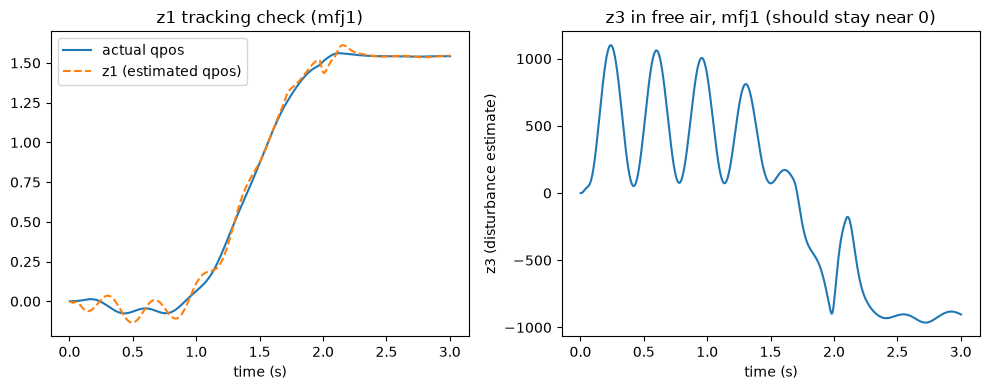

In [16]:
# Free Air Validation
# Before trusting the observer against real contact data, check it behaves
# sanely with no real disturbance present: run the normal open->close motion
# with an empty hand (scene_right.xml has no object), and confirm z1 tracks
# the real qpos closely, and z3 stays small (since there's genuinely nothing
# for it to be estimating here).
b0 = 15662.7416
mfj1_dof_name = "mfj1"

wo = 50.0   # observer bandwidth
beta1 = 3 * wo
beta2 = 3 * wo**2
beta3 = wo**3

model_test = mujoco.MjModel.from_xml_path("mujoco_menagerie/wonik_allegro/scene_right.xml")
data_test = mujoco.MjData(model_test)

mfj1_dof  = model_test.joint(mfj1_dof_name).dofadr[0]
mfj1_qpos = model_test.joint(mfj1_dof_name).qposadr[0]

mujoco.mj_resetData(model_test, data_test)
z1, z2, z3 = 0.0, 0.0, 0.0 # observer's internal state, all start at zero
dt = model_test.opt.timestep
t_log, z1_log, z3_log, qpos_log = [], [], [], []

# Standard motion: brief opening ramp, then closing ramp. No lift here
# this test is purely about the closing motion's effect on the observer
while data_test.time < 3.0:
    if data_test.time < 0.3:
        set_finger_targets(data_test, get_opening_pose(data_test.time))
    else:
        set_finger_targets(data_test, get_closing_pose(data_test.time))
    mujoco.mj_step(model_test, data_test)
    # required for cfrc_ext to be populated. mj_step alone does not
    # compute per-body external force; this ground-truth reading is
    # what we're comparing the observer's estimate against.
    x1_meas = data_test.qpos[mfj1_qpos] # real measured joint angle
    u = data_test.qfrc_actuator[mfj1_dof] + data_test.qfrc_passive[mfj1_dof]

    e = x1_meas - z1 # error function 
    z1 += dt * (z2 + beta1 * e) # estimated joint position (tracks qpos)
    z2 += dt * (b0 * u + z3 + beta2 * e) # estimated joint velocity
    z3 += dt * (beta3 * e) # estimated total disturbance torque acting on the joint 

    t_log.append(data_test.time); z1_log.append(z1); z3_log.append(z3); qpos_log.append(x1_meas)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t_log, qpos_log, label="actual qpos")
plt.plot(t_log, z1_log, '--', label="z1 (estimated qpos)")
plt.xlabel("time (s)"); plt.legend(); plt.title("z1 tracking check (mfj1)")
plt.subplot(1,2,2)
plt.plot(t_log, z3_log)
plt.xlabel("time (s)"); plt.ylabel("z3 (disturbance estimate)")
plt.title("z3 in free air, mfj1 (should stay near 0)")
plt.tight_layout()
plt.show()

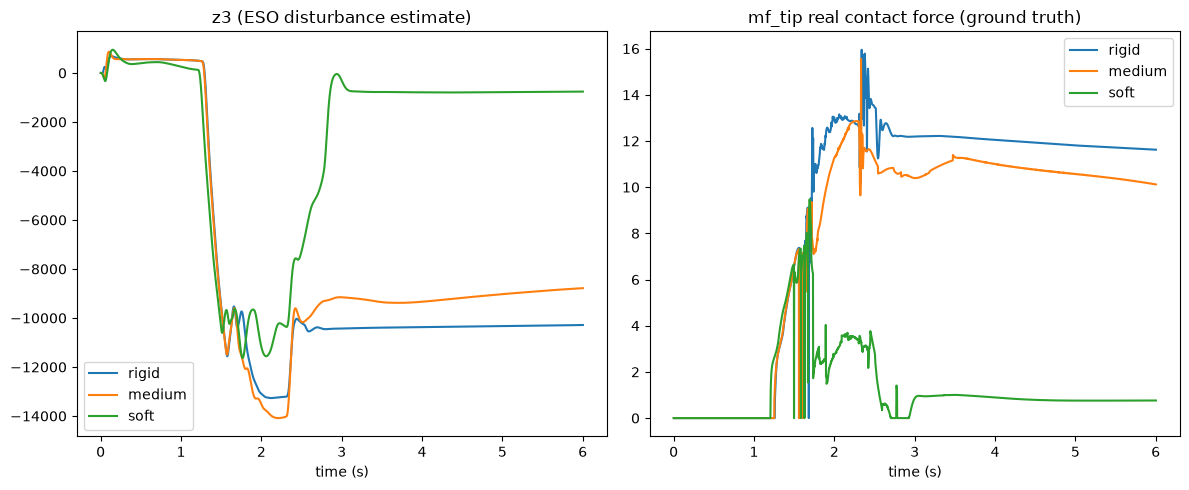

In [17]:
# Runs a full open->close->lift grasp trial on the given scene, with the
# ESO running alongside the real simulation. Returns both the observer's
# disturbance estimate (z3) and the ground-truth contact force
# (cfrc_ext) at every timestep, so they can be compared directly.
def run_eso_grasp_trial(xml_path, obj_name, label, b0, wo=50.0, duration=6.0):
    beta1 = 3*wo
    beta2 = 3 * wo**2
    beta3 = wo**3

    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)

    mfj1_dof  = model.joint("mfj1").dofadr[0]
    mfj1_qpos = model.joint("mfj1").qposadr[0]
    mf_tip_id = model.body("mf_tip").id

    mujoco.mj_resetData(model, data)
    z1, z2, z3 = 0.0, 0.0, 0.0
    dt = model.opt.timestep

    results = {"label": label, "t": [], "z3": [], "mf_force": []}

    # Phase 1: open + lower. 
    # Phase 2: close while still lowered.
    # Phase 3: hold closed pose + lift.
    while data.time < duration:
        if data.time < 0.3:
            set_finger_targets(data, get_opening_pose(data.time))
            set_lift(data, LIFT_DOWN)
        elif data.time < 2.3:
            set_finger_targets(data, get_closing_pose(data.time, start=0.6, duration=1.5))
            set_lift(data, LIFT_DOWN)
        else:
            set_finger_targets(data, CLOSED_POSE)
            set_lift(data, LIFT_UP)

        mujoco.mj_step(model, data)
        mujoco.mj_rnePostConstraint(model, data)   # for real cfrc_ext ground truth

        x1_meas = data.qpos[mfj1_qpos]
        u = data.qfrc_actuator[mfj1_dof] + data.qfrc_passive[mfj1_dof]
        e = x1_meas - z1
        z1 += dt * (z2 + beta1 * e)
        z2 += dt * (b0 * u + z3 + beta2 * e)
        z3 += dt * (beta3 * e)

        results["t"].append(data.time)
        results["z3"].append(z3)
        results["mf_force"].append(np.linalg.norm(data.cfrc_ext[mf_tip_id, 3:6]))

    return results

b0 = 15662.7416
res_rigid_eso = run_eso_grasp_trial("mujoco_menagerie/wonik_allegro/custom_scene.xml", "object", "rigid", b0)
res_medium_eso = run_eso_grasp_trial("mujoco_menagerie/wonik_allegro/custom_scene1.xml", "object1", "medium", b0)
res_soft_eso  = run_eso_grasp_trial("mujoco_menagerie/wonik_allegro/custom_scene2.xml", "object2", "soft", b0)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for res in [res_rigid_eso, res_medium_eso, res_soft_eso]:
    axes[0].plot(res["t"], res["z3"], label=res["label"])
    axes[1].plot(res["t"], res["mf_force"], label=res["label"])
axes[0].set_title("z3 (ESO disturbance estimate)"); axes[0].set_xlabel("time (s)"); axes[0].legend()
axes[1].set_title("mf_tip real contact force (ground truth)"); axes[1].set_xlabel("time (s)"); axes[1].legend()
plt.tight_layout()
plt.savefig("eso_validation.png", dpi=150)
plt.show()

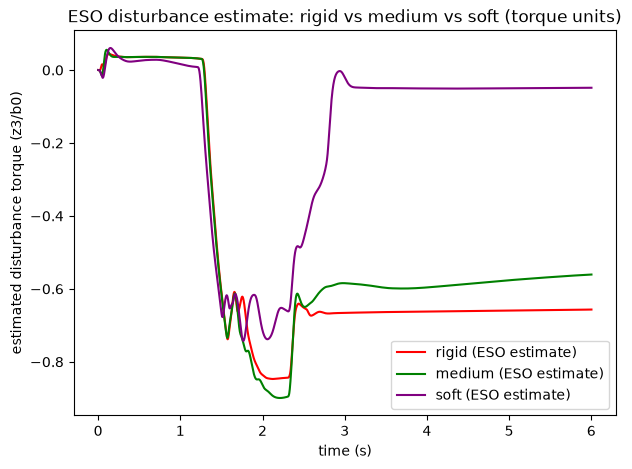

In [18]:
# Convert z3 into torque units for a more interpretable comparison
# z3 is in the same units as qacc (rad/s^2, scaled by b0's units), not
# Newtons, and not directly comparable to cfrc_ext's Newton values. Dividing
# by b0 converts it to an estimated disturbance torque, which is at least a
# physically meaningful quantity, even though it's still not the same
# physical quantity as a Cartesian tip force (this is a single joint's
# torque estimate, not a fingertip force sensor).
torque_est_rigid = np.array(res_rigid_eso["z3"]) / b0
torque_est_medium = np.array(res_medium_eso["z3"]) / b0
torque_est_soft  = np.array(res_soft_eso["z3"]) / b0

plt.figure(figsize=(7,5))
plt.plot(res_rigid_eso["t"], torque_est_rigid, color="red", label="rigid (ESO estimate)")
plt.plot(res_medium_eso["t"], torque_est_medium, color="green", label="medium (ESO estimate)")
plt.plot(res_soft_eso["t"], torque_est_soft, color="purple", label="soft (ESO estimate)")
plt.xlabel("time (s)"); plt.ylabel("estimated disturbance torque (z3/b0)")
plt.legend(); plt.title("ESO disturbance estimate: rigid vs medium vs soft (torque units)")
plt.savefig("eso_torque_estimate.png", dpi=150)
plt.show()

In [24]:
"""Quantifies how well z3 tracks real contact force during the contact
    window (t > contact_start), using two measures:
      - correlation: do z3 and real force rise/fall together over time?
      - peak ratio: how does the biggest z3 spike compare to the biggest
        real force spike? (Note: peaks capture the initial-contact impact
        transient, which turns out to look similar across stiffness levels. """
def compute_validation_metrics(res, label, contact_start=1.3):
    t = np.array(res["t"])
    z3 = np.array(res["z3"])
    force = np.array(res["mf_force"])

    mask = t > contact_start
    z3_c = z3[mask]
    force_c = force[mask]

    # correlation between disturbance estimate and real force during contact
    corr = np.corrcoef(z3_c, force_c)[0, 1]

    peak_z3 = np.max(np.abs(z3_c))
    peak_force = np.max(force_c)

    print(f"--- {label} ---")
    print(f"  correlation (|z3| vs real force, t>{contact_start}s): {corr:.4f}")
    print(f"  peak |z3|:    {peak_z3:.2f}")
    print(f"  peak force:   {peak_force:.2f} N")
    print(f"  ratio peak|z3|/peak_force: {peak_z3/peak_force:.2f}")
    print()

    return {"label": label, "corr": corr, "peak_z3": peak_z3, "peak_force": peak_force}

# z3's sign is a modeling artifact of how contact reaction happens to act on
# mfj1's rotation direction: it has no independent physical meaning here,
# so we flip the sign (-z3) purely to make the numbers positive/comparable;
# only the magnitude of z3 is meaningful.
metrics_rigid = compute_validation_metrics(
    {"t": res_rigid_eso["t"], "z3": -np.array(res_rigid_eso["z3"]), "mf_force": res_rigid_eso["mf_force"]},
    "rigid"
)
metrics_rigid = compute_validation_metrics(
    {"t": res_medium_eso["t"], "z3": -np.array(res_medium_eso["z3"]), "mf_force": res_medium_eso["mf_force"]},
    "medium"
)
metrics_soft = compute_validation_metrics(
    {"t": res_soft_eso["t"], "z3": -np.array(res_soft_eso["z3"]), "mf_force": res_soft_eso["mf_force"]},
    "soft"
)

print(f"Peak |z3| ratio (rigid/soft): {metrics_rigid['peak_z3']/metrics_soft['peak_z3']:.2f}")
print(f"Peak force ratio (rigid/soft): {metrics_rigid['peak_force']/metrics_soft['peak_force']:.2f}")

--- rigid ---
  correlation (|z3| vs real force, t>1.3s): 0.6853
  peak |z3|:    13268.24
  peak force:   15.95 N
  ratio peak|z3|/peak_force: 831.83

--- medium ---
  correlation (|z3| vs real force, t>1.3s): 0.4752
  peak |z3|:    14084.52
  peak force:   15.55 N
  ratio peak|z3|/peak_force: 905.61

--- soft ---
  correlation (|z3| vs real force, t>1.3s): 0.7694
  peak |z3|:    11633.60
  peak force:   9.48 N
  ratio peak|z3|/peak_force: 1227.35

Peak |z3| ratio (rigid/soft): 1.21
Peak force ratio (rigid/soft): 1.64


In [20]:
""" Measures z3 and real force after the initial contact transient has
settled (default: last 1 second of the trial). This turned out to be
the more informative comparison than peak values. The transient spike
right at first contact looks similar across stiffness levels, but the
settled/holding value separates rigid vs medium vs soft clearly, and
that separation closely matches the real force data's separation."""
def compute_steady_state_metrics(res, label, window_start=None, window_end=None):
    t = np.array(res["t"])
    z3 = np.array(res["z3"])
    force = np.array(res["mf_force"])

    if window_start is None:
        window_start = t.max() - 1.0   # last 1 second of the trial
    if window_end is None:
        window_end = t.max()

    mask = (t >= window_start) & (t <= window_end)
    z3_ss = np.mean(np.abs(z3[mask]))
    force_ss = np.mean(force[mask])

    print(f"--- {label} (steady-state, t={window_start:.1f}-{window_end:.1f}s) ---")
    print(f"  mean |z3|:   {z3_ss:.2f}")
    print(f"  mean force:  {force_ss:.2f} N")
    print()
    return {"label": label, "z3_ss": z3_ss, "force_ss": force_ss}

ss_rigid = compute_steady_state_metrics(res_rigid_eso, "rigid")
ss_soft  = compute_steady_state_metrics(res_soft_eso, "soft")

print(f"Steady-state |z3| ratio (rigid/soft): {ss_rigid['z3_ss']/ss_soft['z3_ss']:.2f}")
print(f"Steady-state force ratio (rigid/soft): {ss_rigid['force_ss']/ss_soft['force_ss']:.2f}")

--- rigid (steady-state, t=5.0-6.0s) ---
  mean |z3|:   10312.75
  mean force:  11.71 N

--- soft (steady-state, t=5.0-6.0s) ---
  mean |z3|:   769.60
  mean force:  0.76 N

Steady-state |z3| ratio (rigid/soft): 13.40
Steady-state force ratio (rigid/soft): 15.46


--- medium (steady-state, t=5.0-6.0s) ---
  mean |z3|:   8897.66
  mean force:  10.36 N

Steady-state |z3| ratios (rigid/medium/soft): 10313 / 8898 / 770
Steady-state force ratios (rigid/medium/soft): 11.71 / 10.36 / 0.76


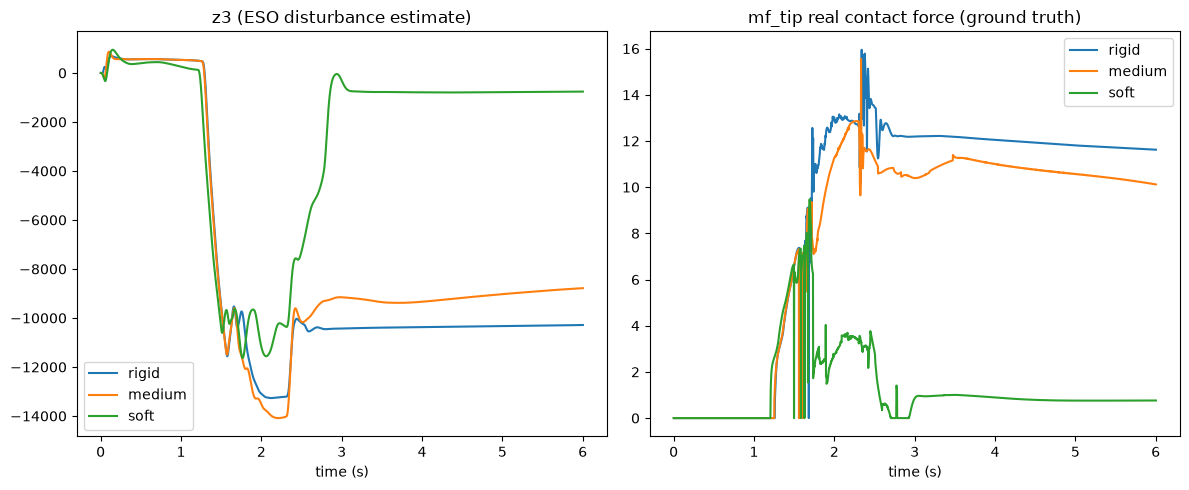

In [21]:
# Add medium into the steady-state comparison, completing the 3-way result.
res_medium_eso = run_eso_grasp_trial(
    "mujoco_menagerie/wonik_allegro/custom_scene1.xml", "object1", "medium", b0
)

ss_medium = compute_steady_state_metrics(res_medium_eso, "medium")

print(f"Steady-state |z3| ratios (rigid/medium/soft): "
      f"{ss_rigid['z3_ss']:.0f} / {ss_medium['z3_ss']:.0f} / {ss_soft['z3_ss']:.0f}")
print(f"Steady-state force ratios (rigid/medium/soft): "
      f"{ss_rigid['force_ss']:.2f} / {ss_medium['force_ss']:.2f} / {ss_soft['force_ss']:.2f}")

# updated 3-way comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for res, label in [(res_rigid_eso, "rigid"), (res_medium_eso, "medium"), (res_soft_eso, "soft")]:
    axes[0].plot(res["t"], res["z3"], label=label)
    axes[1].plot(res["t"], res["mf_force"], label=label)
axes[0].set_title("z3 (ESO disturbance estimate)"); axes[0].set_xlabel("time (s)"); axes[0].legend()
axes[1].set_title("mf_tip real contact force (ground truth)"); axes[1].set_xlabel("time (s)"); axes[1].legend()
plt.tight_layout()
plt.savefig("eso_validation_3way.png", dpi=150)
plt.show()

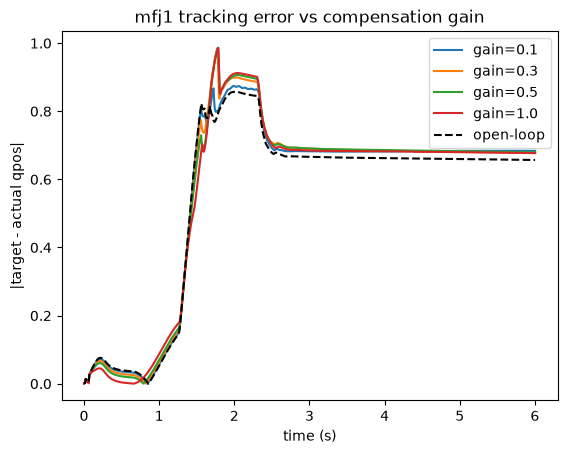

In [23]:
def run_adrc_trial(xml_path, obj_name, label, b0, wo=50.0, compensate=True, comp_gain=1.0):
    """
    ADRC (Active Disturbance Rejection Control) attempt: feed z3 back into
    the control signal to try to cancel the estimated disturbance, rather
    than just observing it. Tested whether this improves mfj1's position-
    tracking accuracy during a real grasp.

    RESULT (documented, not fixed further): tracking error got worse with
    higher compensation gain, monotonically. Root cause: z3 is negative
    during contact, so subtracting it from the target pushes the finger
    further in the closing direction: compensation makes the finger
    push harder into the object, which isn't actually a better grasp, it's
    fighting the contact that defines the grasp in the first place. Naive
    ADRC (designed to keep a system doing what it was already trying to do)
    is the wrong tool right at the moment tracking should deviate from the
    open-air target. That deviation is what a grasp is.
    """
    beta1, beta2, beta3 = 3*wo, 3*wo**2, wo**3
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)
    mfj1_dof, mfj1_qpos = model.joint("mfj1").dofadr[0], model.joint("mfj1").qposadr[0]

    mujoco.mj_resetData(model, data)
    z1, z2, z3 = 0.0, 0.0, 0.0
    dt = model.opt.timestep
    results = {"label": label, "t": [], "qpos": [], "target": [], "tracking_error": [], "correction": []}

    while data.time < 6.0:
        if data.time < 0.3:
            pose = get_opening_pose(data.time)
        elif data.time < 2.3:
            pose = get_closing_pose(data.time, start=0.6, duration=1.5)
        else:
            pose = CLOSED_POSE.copy()

        target_mfj1 = pose[5]   # mfj1's target within the 16-array
        correction = comp_gain * z3 / b0 if compensate else 0.0
        data.ctrl[6] = target_mfj1 - correction   # ctrl index 6 = mfj1's actuator (ctrl array includes lift at index 0)
        for i, v in enumerate(pose):
            if i != 5:
                data.ctrl[i+1] = v
        set_lift(data, LIFT_DOWN if data.time < 2.3 else LIFT_UP)

        mujoco.mj_step(model, data)
        x1_meas = data.qpos[mfj1_qpos]
        u = data.qfrc_actuator[mfj1_dof] + data.qfrc_passive[mfj1_dof]
        e = x1_meas - z1
        z1 += dt*(z2 + beta1*e); z2 += dt*(b0*u + z3 + beta2*e); z3 += dt*(beta3*e)

        results["t"].append(data.time)
        results["qpos"].append(x1_meas)
        results["target"].append(target_mfj1)
        results["tracking_error"].append(abs(target_mfj1 - x1_meas))
        results["correction"].append(correction)

    return results

xml = "mujoco_menagerie/wonik_allegro/custom_scene.xml"
res_open = run_adrc_trial(xml, "object", "open-loop", b0, compensate=False)

for gain in [0.1, 0.3, 0.5, 1.0]:
    res = run_adrc_trial(xml, "object", f"gain={gain}", b0, compensate=True, comp_gain=gain)
    plt.plot(res["t"], res["tracking_error"], label=f"gain={gain}")

plt.plot(res_open["t"], res_open["tracking_error"], '--', color='black', label="open-loop")
plt.xlabel("time (s)"); plt.ylabel("|target - actual qpos|"); plt.legend()
plt.title("mfj1 tracking error vs compensation gain")
plt.show()